<a href="https://colab.research.google.com/github/one-2730/ESAA-24-2/blob/Session/ESAA_YB_1129_Session.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **kMeans 알고리즘을 적용하여 확인적 군집분석을 수행하시오.**
>변수 설명 ) tot_price : 총구매액, buy_count : 구매횟수,
                   visit_count : 매장방문횟수, avg_price : 평균구매액

In [1]:
#필요한 모듈 불러오기
import pandas as pd
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_samples, silhouette_score

## 1) 데이터 불러오기 및 탐색

In [2]:
sales = pd.read_csv("product_sales.csv")
print(sales.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   tot_price    150 non-null    float64
 1   visit_count  150 non-null    float64
 2   buy_count    150 non-null    float64
 3   avg_price    150 non-null    float64
dtypes: float64(4)
memory usage: 4.8 KB
None


In [3]:
print(sales.shape)
print(type(sales))

(150, 4)
<class 'pandas.core.frame.DataFrame'>


## 2) KMeans 를 이용하여 3개의 군집으로 군집화

2-1) KMeans 모델을 생성하세요. 군집은 3개로 군집화하세요.

In [4]:
#모델 생성

from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters = 3)

2-2) 모델을 훈련하고 예측치 생성하고 이 결과를 pred라는 변수에 저장하세요.

In [5]:
pred  = kmeans.fit_predict(sales)
pred

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 0, 2, 0, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 0, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 0, 2, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0,
       2, 2, 0, 0, 0, 0, 2, 0, 2, 0, 2, 0, 0, 2, 2, 0, 0, 0, 0, 0, 2, 0,
       0, 0, 0, 2, 0, 0, 0, 2, 0, 0, 0, 2, 0, 0, 2, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1], dtype=int32)

2-3) 원형 데이터(scale)에 예측치(변수명:cluster)를 추가하세요.

In [6]:
sales['cluster'] = pred
sales.head()

,tot_price,visit_count,buy_count,avg_price,cluster
0,5.0,0.2,3.0,1.6,1
1,5.0,0.4,3.4,1.6,1
2,5.2,0.2,3.5,1.5,1
3,5.2,0.2,3.0,1.4,1
4,4.7,0.2,3.2,1.6,1


## 3) 군집화 시각화
: 전체 데이터를 2차원으로 축소한 뒤 시각화하세요.

3-1) cluster 변수를 제외한 sales 데이터를 salesDF라는 이름으로 변수에 저장하세요.

In [7]:
salesDF = sales.drop('cluster', axis = 1)

3-2) salesDF 데이터를 이용하여 2차원으로 차원축소 한 후 그 결과를 sales에 pca_x, pca_y 이름으로 저장하세요.

In [8]:
#차원 축소 한 후 변형된 값 임의의 변수에 저장
from sklearn.decomposition import PCA

pca = PCA(n_components = 2)
sales_pca = pca.fit_transform(salesDF)

#sales에 'pca_x', 'pca_y' 이름으로 열 만들어 저장
sales[['pca_x', 'pca_y']] = sales_pca
sales.head()

,tot_price,visit_count,buy_count,avg_price,cluster,pca_x,pca_y
0,5.0,0.2,3.0,1.6,1,-2.516330,-0.074159
1,5.0,0.4,3.4,1.6,1,-2.466679,0.231335
2,5.2,0.2,3.5,1.5,1,-2.557365,0.456400
3,5.2,0.2,3.0,1.4,1,-2.615332,0.073586
4,4.7,0.2,3.2,1.6,1,-2.636320,-0.087265


3-3) pca_x를 x축, pca_y를 y축으로 하여 산점도를 그리세요. 색으로 각 점이 군집에 따라 구분되도록 하세요. (단, 각 군집별로 마커 모양 구분하지 않고 오직 색으로만 구분합니다.)

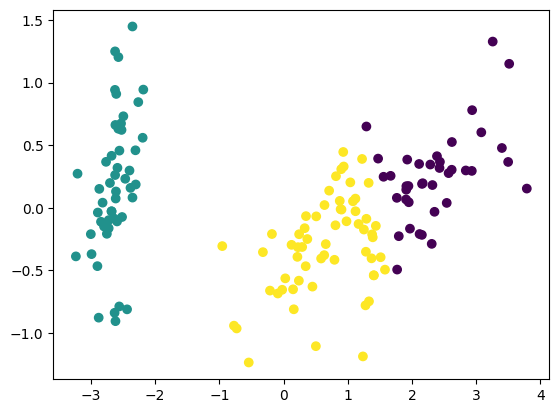

In [9]:
import matplotlib.pyplot as plt

plt.scatter(sales['pca_x'], sales['pca_y'], c = sales['cluster'])

plt.show()

## 4) 군집평가: 실루엣 계수 구하기

In [10]:
#시각화를 위하여 사용했던 차원 축소 관련 계수 삭제
sales=sales.drop(['pca_x','pca_y'], axis=1)

#cluster 행을 제외한 순수 데이터 sales_data로 저장
sales_data=sales.drop('cluster', axis=1)

4-1) sales의 모든 데이터에 실루엣 계수를 구하고 실루엣 계수 칼럼을 추가하세요.

In [11]:
#sales의 모든 데이터에 실루엣 계수 구하기
from sklearn.metrics import silhouette_samples

sil_score = silhouette_samples(sales, sales['cluster'])
sil_score

array([0.80014944, 0.81195377, 0.81525102, 0.79727726, 0.80869027,
       0.81044204, 0.75490444, 0.73288728, 0.69545286, 0.82049429,
       0.82149088, 0.77483022, 0.82049429, 0.77030412, 0.82695392,
       0.82311363, 0.67120678, 0.78053551, 0.7784147 , 0.72168837,
       0.80958791, 0.78184021, 0.81022439, 0.7888789 , 0.83414863,
       0.42720233, 0.6256937 , 0.50305191, 0.68248431, 0.63133225,
       0.7210575 , 0.64427077, 0.32368096, 0.60393624, 0.63568147,
       0.40887133, 0.71622523, 0.65389398, 0.68907359, 0.59810767,
       0.57565309, 0.69990028, 0.70910919, 0.69036956, 0.67442933,
       0.61126538, 0.70426533, 0.60745491, 0.66974975, 0.66941539,
       0.61413544, 0.5144569 , 0.56077757, 0.71732946, 0.54398195,
       0.63185302, 0.58864219, 0.70562051, 0.59736315, 0.67711877,
       0.62796942, 0.53903222, 0.64870997, 0.71123498, 0.70134964,
       0.70540638, 0.69534651, 0.71924804, 0.34598359, 0.72836538,
       0.71579114, 0.72929678, 0.70446987, 0.17502299, 0.73040

In [12]:
#sales에 실루엣 계수 칼럼 추가

sales['sil_score'] = sil_score
sales.head()

,tot_price,visit_count,buy_count,avg_price,cluster,sil_score
0,5.0,0.2,3.0,1.6,1,0.800149
1,5.0,0.4,3.4,1.6,1,0.811954
2,5.2,0.2,3.5,1.5,1,0.815251
3,5.2,0.2,3.0,1.4,1,0.797277
4,4.7,0.2,3.2,1.6,1,0.808690


4-2) 모든 데이터의 평균 실루엣 계수를 구하세요.

In [13]:
#모든 데이터의 평균 실루엣 계수 값을 구하기
import numpy as np

np.mean(sales['sil_score'])

0.6703860916826776

4-3) 군집별 평균 실루엣 계수를 구하세요.

In [14]:
#군집별 평균 실루엣 계수 구하기
sales.groupby(['cluster'])['sil_score'].mean()

,sil_score
cluster,
0,0.634144
1,0.764630
2,0.616308
